<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/EDA_Tourism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umeradnaan/tourism-dataset")

print("Path to dataset files:", path)

100%|██████████| 140k/140k [00:00<00:00, 55.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/umeradnaan/tourism-dataset/versions/1


In [3]:
import os
os.listdir(path)

['tourism_dataset.csv']

In [4]:
file_path = path+'/tourism_dataset.csv'
df = pd.read_csv(file_path)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Location                 5989 non-null   object 
 1   Country                  5989 non-null   object 
 2   Category                 5989 non-null   object 
 3   Visitors                 5989 non-null   int64  
 4   Rating                   5989 non-null   float64
 5   Revenue                  5989 non-null   float64
 6   Accommodation_Available  5989 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 327.7+ KB


In [6]:
df.describe()

,Visitors,Rating,Revenue
count,5989.000000,5989.000000,5989.000000
mean,501016.089497,3.009347,499479.367253
std,289783.294978,1.155980,286743.225211
min,1108.000000,1.000000,1025.810000
25%,252789.000000,2.010000,251410.450000
50%,500831.000000,3.000000,494169.350000
75%,751371.000000,4.010000,742241.240000
max,999982.000000,5.000000,999999.490000


In [7]:
df.isna().sum()

,0
Location,0
Country,0
Category,0
Visitors,0
Rating,0
Revenue,0
Accommodation_Available,0


In [8]:
df.head()

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,kuBZRkVsAR,India,Nature,948853,1.32,84388.38,Yes
1,aHKUXhjzTo,USA,Historical,813627,2.01,802625.60,No
2,dlrdYtJFTA,Brazil,Nature,508673,1.42,338777.11,Yes
3,DxmlzdGkHK,Brazil,Historical,623329,1.09,295183.60,Yes
4,WJCCQlepnz,France,Cultural,124867,1.43,547893.24,No


In [9]:
df = df.drop('Location', axis = 1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  5989 non-null   object 
 1   Category                 5989 non-null   object 
 2   Visitors                 5989 non-null   int64  
 3   Rating                   5989 non-null   float64
 4   Revenue                  5989 non-null   float64
 5   Accommodation_Available  5989 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 280.9+ KB


In [11]:
plt.style.use('fivethirtyeight')

In [13]:
country_and_visitors = df.groupby('Country')['Visitors'].sum().reset_index()
country_and_visitors

,Country,Visitors
0,Australia,416038005
1,Brazil,414293518
2,China,404448372
3,Egypt,458573652
4,France,424944621
5,India,451083005
6,USA,431204187


<BarContainer object of 7 artists>

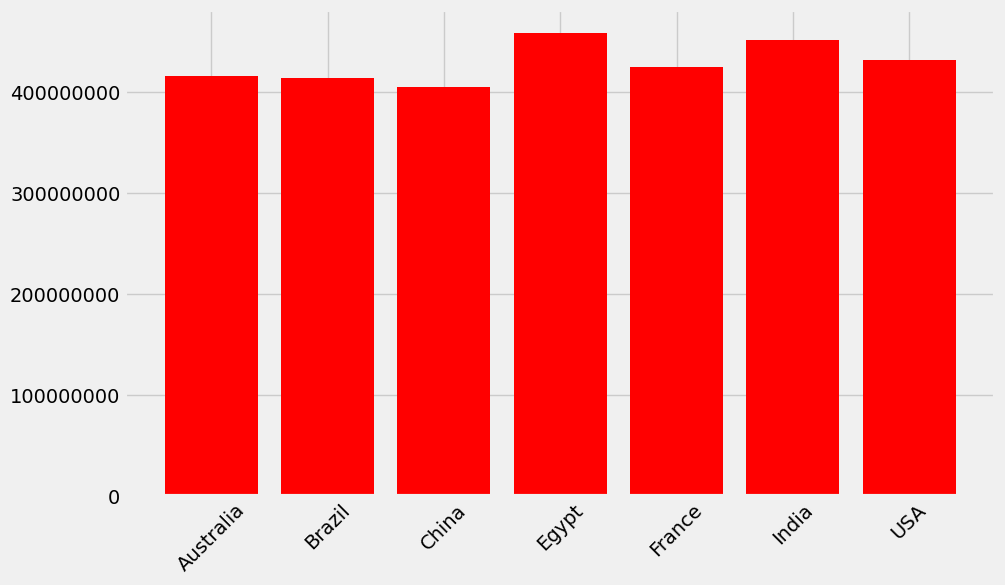

In [14]:
plt.figure(figsize = (10, 6))
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 45)
plt.bar(country_and_visitors['Country'], country_and_visitors['Visitors'], color = 'red')

In [15]:
df['Category'].unique()

array(['Nature', 'Historical', 'Cultural', 'Beach', 'Adventure', 'Urban'],
      dtype=object)

([<matplotlib.patches.Wedge at 0x7aa6d2248ec0>,
 [Text(0.9645593597176946, 0.5287960302243117, 'Nature'),
  Text(0.051047521389544236, 1.098814884573368, 'Historical'),
  Text(-0.9247261314112691, 0.5957193818276759, 'Cultural'),
  Text(-0.9783590549112463, -0.5028056877892028, 'Beach'),
  Text(-0.03144282797097697, -1.0995505211536156, 'Adventure'),
  Text(0.9503601654968615, -0.5539093390048394, 'Urban')],
 [Text(0.5261232871187425, 0.28843419830417, '15.96%'),
  Text(0.027844102576115033, 0.5993535734036552, '16.60%'),
  Text(-0.504396071678874, 0.32493784463327774, '16.66%'),
  Text(-0.5336503935879524, -0.27425764788501966, '16.66%'),
  Text(-0.017150633438714712, -0.5997548297201539, '17.32%'),
  Text(0.5183782720891972, -0.30213236672991234, '16.80%')])

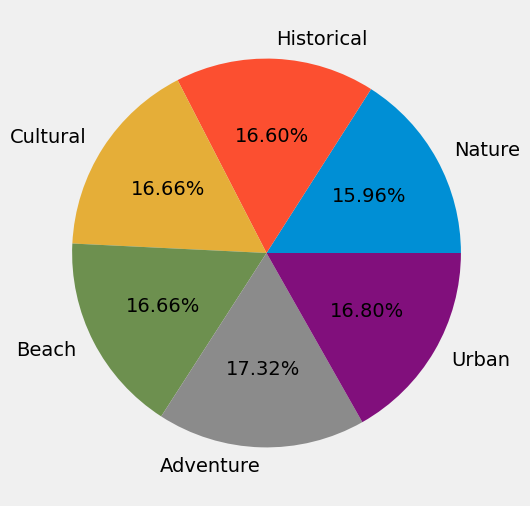

In [16]:
nature = df['Category'].value_counts()['Nature']
historical = df['Category'].value_counts()['Historical']
cultural = df['Category'].value_counts()['Cultural']
beach = df['Category'].value_counts()['Beach']
adventure = df['Category'].value_counts()['Adventure']
urban = df['Category'].value_counts()['Urban']

values = [nature, historical, cultural, beach, adventure, urban]
labels = ['Nature', 'Historical', 'Cultural', 'Beach', 'Adventure', 'Urban']

plt.figure(figsize = (10, 6))
plt.pie(values, labels = labels, autopct = '%1.2f%%')

In [17]:
df['Accommodation_Available'].unique()

array(['Yes', 'No'], dtype=object)

([<matplotlib.patches.Wedge at 0x7aa6d15eed50>,
 [Text(-0.010674798224117286, 1.0999482027272351, 'Yes'),
  Text(0.01067436988847106, -1.0999482068840716, 'No')],
 [Text(-0.005822617213154883, 0.5999717469421282, '50.31%'),
  Text(0.005822383575529669, -0.5999717492094935, '49.69%')])

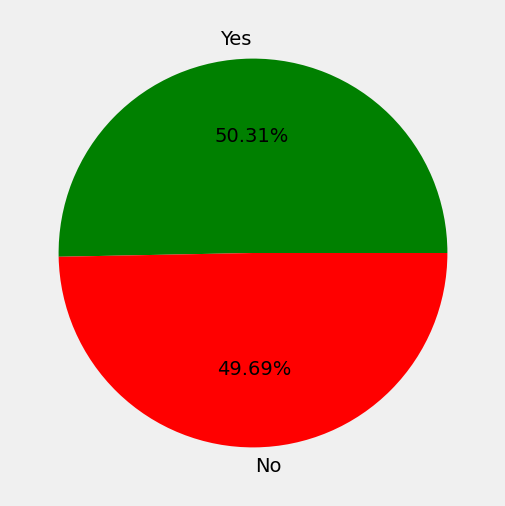

In [18]:
yes_ac = df['Accommodation_Available'].value_counts()['Yes']
no_ac = df['Accommodation_Available'].value_counts()['No']

values = [yes_ac, no_ac]
labels = ['Yes', 'No']
colors = ['green', 'red']

plt.figure(figsize = (10, 6))
plt.pie(values, labels = labels, colors = colors, autopct = '%1.2f%%')

<Axes: xlabel='Country', ylabel='Rating'>

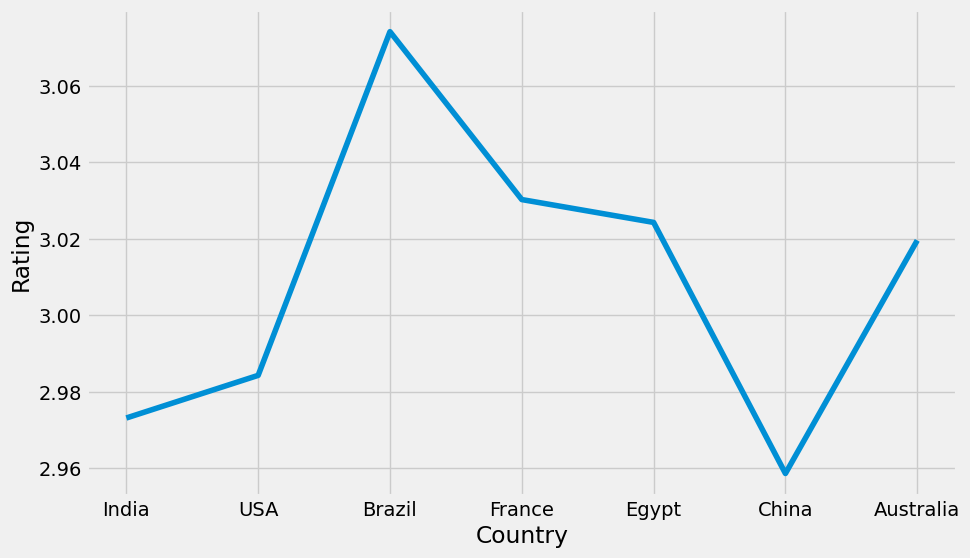

In [19]:
plt.figure(figsize = (10, 6))
sns.lineplot(data = df, x = 'Country', y = 'Rating', ci = None)

<Axes: xlabel='Country', ylabel='Revenue'>

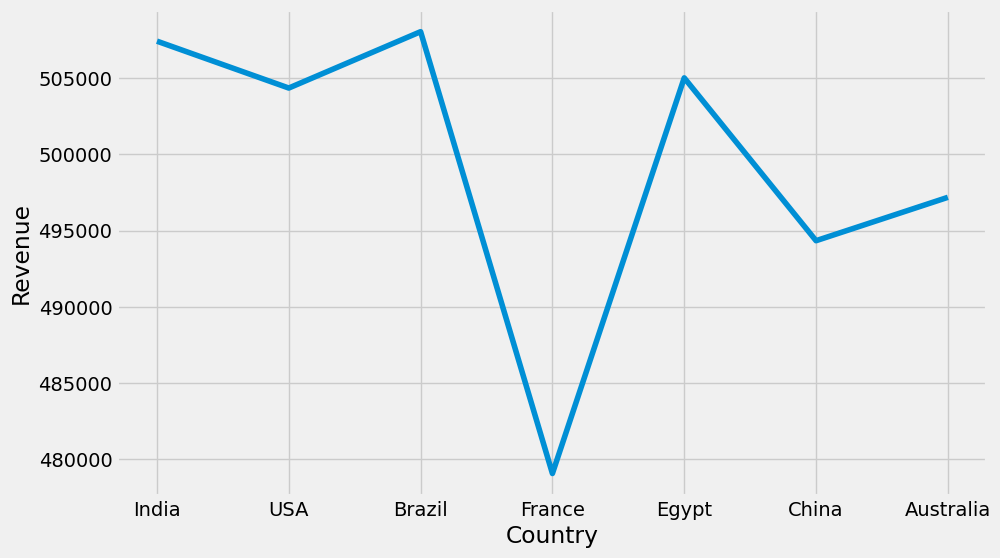

In [20]:
plt.figure(figsize = (10, 6))
sns.lineplot(data = df, x = 'Country', y = 'Revenue', ci = None)

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

In [22]:
le = LabelEncoder()

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = le.fit_transform(df[col])

In [23]:
df.head(3)

,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,5,4,948853,1.32,84388.38,1
1,6,3,813627,2.01,802625.60,0
2,1,4,508673,1.42,338777.11,1


In [24]:
scaler = MinMaxScaler()
df['Visitors'] = scaler.fit_transform(df['Visitors'].values.reshape(-1, 1))
df['Revenue'] = scaler.fit_transform(df['Revenue'].values.reshape(-1, 1))

In [25]:
df.head()

,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,5,4,0.948813,1.32,0.083448,1
1,6,3,0.813435,2.01,0.802423,0
2,1,4,0.508137,1.42,0.338098,1
3,1,3,0.622922,1.09,0.294460,1
4,4,2,0.123899,1.43,0.547429,0


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [27]:
y = df['Revenue']
x = df.drop('Revenue', axis = 1)

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, train_size = 0.75)

In [29]:
lr = LinearRegression()
lr.fit(x_train, y_train)
pred_lr = lr.predict(x_test)
lr_mse = mean_squared_error(y_test, pred_lr)
lr_r2 = r2_score(y_test, pred_lr)
print(lr_mse)
print(lr_r2)

0.08181427849620453
-0.0066662072766388025


In [30]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)
rf_mse = mean_squared_error(y_test, pred_rf)
rf_r2 = r2_score(y_test, pred_rf)
print(rf_mse)
print(rf_r2)

0.08975325583951811
-0.10434964785381662


In [31]:
xg = XGBRegressor()
xg.fit(x_train, y_train)
pred_xg = xg.predict(x_test)
xg_mse = mean_squared_error(y_test, pred_xg)
xg_r2 = r2_score(y_test, pred_xg)
print(xg_mse)
print(xg_r2)

0.09899993523121658
-0.21812342725072198


<Axes: title={'center': 'MSE Scores'}>

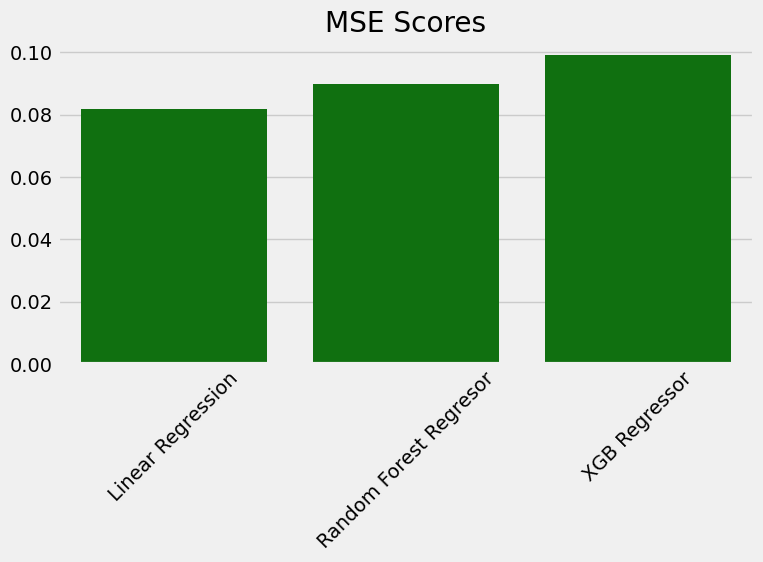

In [32]:
plt.figure(figsize = (8, 4))
plt.xticks(rotation = 45)
plt.title('MSE Scores')
sns.barplot(y = [lr_mse, rf_mse, xg_mse], x = ['Linear Regression', 'Random Forest Regresor', 'XGB Regressor'], color = 'Green')

<Axes: title={'center': 'R2 Scores'}>

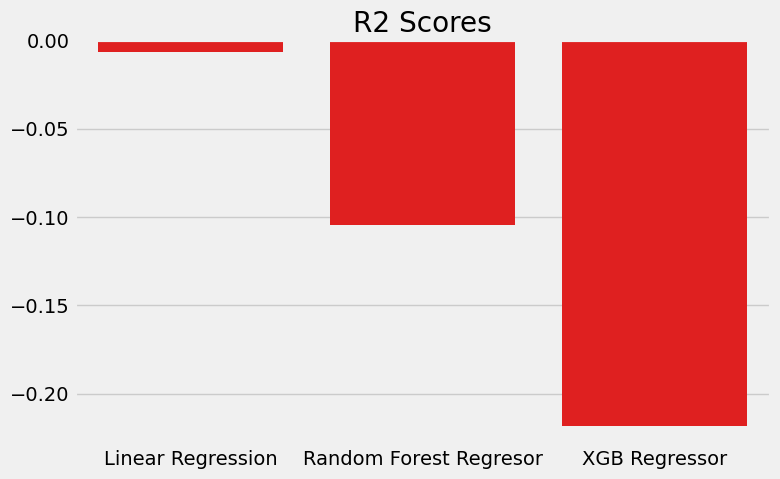

In [33]:
plt.figure(figsize = (8, 5))
plt.title('R2 Scores')
sns.barplot(x = ['Linear Regression', 'Random Forest Regresor', 'XGB Regressor'], y = [lr_r2, rf_r2, xg_r2], color = 'red')